# Chatbot reading existing memories

In [7]:
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage,HumanMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------

store=InMemoryStore()

user_id = "u1"

user_details = ("user", user_id, "details")
# user_details is nothing but a folder where we sotre the respective long therm meory
store.put(user_details,"profile-1",{"data":"Name:Sudhanva"})
store.put(user_details,"profile-2",{"data":"Profession:Engineer graduate with aiml degreee"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [3]:
store.get(user_details,"profile-1")

Item(namespace=['user', 'u1', 'details'], key='profile-1', value={'data': 'Name:Sudhanva'}, created_at='2026-06-03T09:00:27.430518+00:00', updated_at='2026-06-03T09:00:27.430518+00:00')

In [5]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, sudhanva...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [6]:
# ----------------------------
# 3) Build graph: START -> chat -> END (read-only LTM)
# ----------------------------
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [8]:
def chat_node(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id=config["configurable"]["user_id"]

    #read only: fetch user details memory(no writes)
    user_details=("user",user_id,"details")
    items=store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    
    if items:
        user_details_content="\n".join(f"- {it.value.get('data','')}" for it in items)

    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg=SystemMessage(content=system_prompt)

    response=llm.invoke([system_msg]+state["messages"])

    return {"messages":[response]}
    

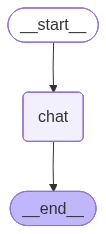

In [9]:
builder=StateGraph(MessagesState)

builder.add_node("chat",chat_node)
builder.add_edge(START,"chat")
builder.add_edge("chat",END)

graph=builder.compile(store=store)
graph

In [10]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [HumanMessage(content="explain genai in simple terms")]},
    config,
)

print(result["messages"][-1].content)

Sure, Sudhanva... Generative AI (GenAI) is a type of artificial intelligence that can create new content, such as images, music, or text, based on patterns it has learned from existing data. Think of it like a very advanced version of a paint program that can generate entire paintings on its own.

In simple terms, GenAI uses complex algorithms to understand the structure and patterns of a particular type of data, and then uses that understanding to generate new, original content that's similar in style and structure.

For example, in your MCP server Python-based project, you could use GenAI to generate new game levels or scenarios based on patterns learned from existing levels.

Here's a simple Python example to illustrate this concept:
```python
import numpy as np

# Let's say we have a dataset of game levels, represented as 2D arrays
levels = [
    np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]]),
    np.array([[1, 1, 0], [0, 0, 1], [0, 1, 1]])
]

# We can use a GenAI model to generate ne

# Chatbot Creating New Memories

In [14]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [3]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [4]:
# ----------------------------
# 2) LLM that decides what to remember (structured output)
# ----------------------------
extractor_llm = ChatGroq(model="llama-3.1-8b-instant",temperature=0)

In [5]:
class MemoryDecision(BaseModel):
    should_write:bool=Field(description="Whether to store any memories")
    memories:List[str]=Field(default_factory=list,description="Atomic user memories to store")
    

In [6]:
memory_extractor=extractor_llm.with_structured_output(MemoryDecision)


In [23]:
# ----------------------------
# 3) Graph: START -> remember -> END
#    (Creates memories, but does NOT use them to answer)
# ----------------------------

def remember_only_node(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id=config["configurable"]["user_id"]

    namespace=("user",user_id,"details")

    # take latest user message
    last_msg = state["messages"][-1].content

    #LLM decides what to store
    decision:MemoryDecision=memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    """
                      Extract LONG-TERM memories from the user's message.

Only store stable, user-specific information such as:
- identity
- preferences
- skills
- background
- ongoing projects
- long-term goals

Do NOT store:
- temporary requests
- greetings
- short-term context
- conversational filler
- transient emotions

IMPORTANT:
- Rewrite memories into clean normalized statements.
- Never store memories in first-person form.
- Convert phrases like "my name is Sudhanva" into "User's name is Sudhanva."
- Convert "I like Python" into "User likes Python."
- Each memory must be atomic, concise, and standalone.
- Avoid copying the user's exact wording.

Return:
- should_write=false if nothing is worth storing.
- otherwise return a list of memories.
"""
                )
            ),
            {"role":"user","content":last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace,str(uuid.uuid4()),{"data":mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

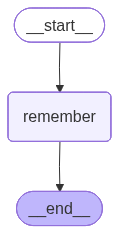

In [24]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [25]:
# ----------------------------
# 4) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Sudhanva"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [26]:
res = graph.invoke({"messages": [{"role": "user", "content": "I love working in the ai domain and learning new things"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [27]:
res=graph.invoke({"messages":[HumanMessage(content="my favorite programming language is Python")]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [28]:
for item in store.search(("user","u1","details")):
    print(item.value['data'])


My name is Sudhanva
I love working in the AI domain
I like Python
My name is Sudhanva
I love working in the AI domain
I like Python
User's name is Sudhanva.
User has interest in AI domain
User's favorite programming language is Python.


# Chatbot Creating New Memories(without Duplication)

In [1]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [4]:
# ----------------------------
# 2) LLM 
#    - memory_llm: extracts candidate memories + tells if each is NEW (no duplicate_of needed)
# ----------------------------
memory_llm = ChatGroq(model="llama-3.1-8b-instant",temperature=0)

In [5]:
class MemoryItem(BaseModel):
    text:str=Field(description="Atomic user memory as a short sentence")
    is_new:bool=Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [6]:
class MemoryDecision(BaseModel):
    should_write:bool=Field(description="Whether to store any memories")
    memories:List[MemoryItem]=Field(default_factory=list,description="Atomic user memories to store")

In [7]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [19]:
MEMORY_PROMPT = """
You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific information worth storing long-term:
  - identity
  - stable preferences
  - ongoing projects
  - long-term goals
  - recurring context

MEMORY WRITING RULES:
- Write every memory as a short standalone third-person fact.
- NEVER store raw first-person statements.
- Convert statements into normalized form.

Examples:
- "I am Sudhanva" -> "User's name is Sudhanva."
- "I live in Bangalore" -> "User lives in Bangalore."
- "I like Python" -> "User prefers Python."
- "I am building a RAG chatbot" -> "User is building a RAG chatbot."

ADDITIONAL RULES:
- Keep each memory atomic and concise.
- No speculation or inferred facts.
- Store only information explicitly stated by the user.
- Avoid temporary or low-value details.
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If the meaning already exists in memory, set is_new=false.
- If nothing memory-worthy exists, return an empty list.
"""

In [9]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [10]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [11]:
config = {"configurable": {"user_id": "u1"}}

In [16]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is sudhu"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [17]:
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [18]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

My name is Nitish
I like Python for programming.
My name is sudhu
